# Run Influence Predictor (inference)

**Luồng:** import → `load_bundle` → `predict_from_payload` → `print_eval_metrics` → đường dẫn → tải model → ví dụ JSON → (tuỳ chọn) đánh giá trên test.


## 1. Import thư viện


In [9]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


## 2. Tải bundle model (`metadata.json` + `joblib`)


In [10]:
def load_bundle(bundle_dir: Path):
    meta_path = bundle_dir / "metadata.json"
    model_path = bundle_dir / "influence_predictor.joblib"
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing metadata: {meta_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Missing model: {model_path}")
    metadata = json.loads(meta_path.read_text(encoding="utf-8"))
    feature_names: list[str] = metadata["feature_names"]
    int_to_label: dict[str, str] = metadata["label_encoder"]["int_to_label"]
    model = joblib.load(model_path)
    return model, metadata, feature_names, int_to_label


## 3. Dự đoán từ JSON (`items` + `vector` hoặc `features`)


In [11]:
def predict_from_payload(
    model: Any,
    feature_names: list[str],
    int_to_label: dict[str, str],
    payload: dict[str, Any],
) -> dict[str, Any]:
    items = payload.get("items")
    if not isinstance(items, list) or not items:
        raise ValueError('Input JSON must contain non-empty list field "items".')
    rows: list[dict[str, Any]] = []
    ids: list[str] = []
    for i, item in enumerate(items):
        if not isinstance(item, dict):
            raise ValueError(f"items[{i}] must be an object.")
        item_id = str(item.get("id", i))
        ids.append(item_id)
        if "vector" in item:
            vec = item["vector"]
            if not isinstance(vec, list) or len(vec) != len(feature_names):
                raise ValueError(
                    f"items[{i}].vector must be a list with length={len(feature_names)} "
                    f'(got {len(vec) if isinstance(vec, list) else "non-list"}).'
                )
            rows.append({fn: float(v) for fn, v in zip(feature_names, vec)})
        elif "features" in item:
            feats = item["features"]
            if not isinstance(feats, dict):
                raise ValueError(f"items[{i}].features must be an object.")
            rows.append({fn: float(feats.get(fn, 0.0)) for fn in feature_names})
        else:
            raise ValueError(f'items[{i}] must contain either "vector" or "features".')
    X = pd.DataFrame(rows, columns=feature_names)
    y_pred_int = model.predict(X).astype(int)
    out: dict[str, Any] = {"predictions": []}
    proba = None
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X)
        except Exception:
            proba = None
    for idx, item_id in enumerate(ids):
        pred_int = int(y_pred_int[idx])
        pred_label = int_to_label.get(str(pred_int), str(pred_int))
        pred_obj: dict[str, Any] = {
            "id": item_id,
            "label_int": pred_int,
            "label": pred_label,
        }
        if proba is not None:
            p = proba[idx]
            pred_obj["proba"] = {
                int_to_label.get(str(k), str(k)): float(p[k]) for k in range(len(p))
            }
            pred_obj["proba_max"] = float(np.max(p))
        out["predictions"].append(pred_obj)
    return out


## 4. In metrics + confusion matrix (dùng khi có nhãn thật)


In [12]:
def print_eval_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    label_order: list[int],
    int_to_label: dict[str, str],
    title: str = "Evaluation",
) -> None:
    labels = np.array(sorted(label_order))
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    names = [int_to_label[str(i)] for i in labels]
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(
        f"Precision — macro: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}, "
        f"weighted: {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}"
    )
    print(
        f"Recall — macro: {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}, "
        f"weighted: {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}"
    )
    print(
        f"F1 — macro: {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}, "
        f"weighted: {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}"
    )
    print(classification_report(y_true, y_pred, labels=labels, target_names=names, digits=4, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names).plot(ax=ax, cmap="Blues", colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## 5. Đường dẫn thư mục bundle


In [13]:
from pathlib import Path

BASE_DIR = Path(".").resolve()
if not (BASE_DIR / "model" / "influence_predictor").exists() and (
    BASE_DIR.parent / "model" / "influence_predictor"
).exists():
    BASE_DIR = BASE_DIR.parent

BUNDLE_DIR = BASE_DIR / "model" / "influence_predictor"
print("BUNDLE_DIR:", BUNDLE_DIR)


BUNDLE_DIR: D:\KLTN4\extraction-system\model\influence_predictor


## 6. Tải model vào bộ nhớ


In [14]:
model, metadata, feature_names, int_to_label = load_bundle(BUNDLE_DIR)
label_order = sorted(int(k) for k in int_to_label.keys())
print("Số feature:", len(feature_names))


Số feature: 40


## 7. Ví dụ inference (một `vector` toàn 0 — thay bằng vector thật)


In [15]:
example = {
    "items": [
        {
            "id": "demo-1",
            "vector": [0.0] * len(feature_names),
        }
    ]
}
out = predict_from_payload(model, feature_names, int_to_label, example)
print(json.dumps(out, ensure_ascii=False, indent=2))


{
  "predictions": [
    {
      "id": "demo-1",
      "label_int": 1,
      "label": "MEDIUM",
      "proba": {
        "LOW": 7.434867775581359e-07,
        "MEDIUM": 0.9999992415572511,
        "HIGH": 1.4955971391871716e-08
      },
      "proba_max": 0.9999992415572511
    }
  ]
}


## 8. (Tuỳ chọn) Đánh giá trên `X_test` / `y_test` nếu có


Accuracy: 0.8885
Precision — macro: 0.8957, weighted: 0.8957
Recall — macro: 0.8883, weighted: 0.8885
F1 — macro: 0.8859, weighted: 0.8860
              precision    recall  f1-score   support

         LOW     0.7986    0.9452    0.8657       365
      MEDIUM     0.9231    0.7253    0.8123       364
        HIGH     0.9654    0.9945    0.9798       365

    accuracy                         0.8885      1094
   macro avg     0.8957    0.8883    0.8859      1094
weighted avg     0.8957    0.8885    0.8860      1094



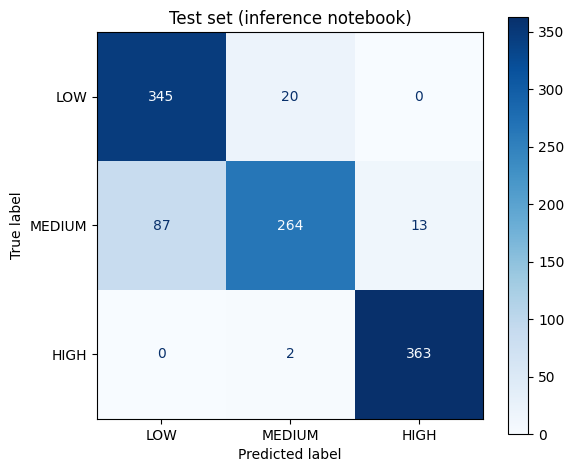

In [16]:
DATA_DIR = BASE_DIR / "feature_engineering_output"
if (DATA_DIR / "X_test.csv").exists() and (DATA_DIR / "y_test.csv").exists():
    X_test = pd.read_csv(DATA_DIR / "X_test.csv")
    y_test = pd.read_csv(DATA_DIR / "y_test.csv")["label_int"].astype(int).to_numpy()
    if list(X_test.columns) != feature_names:
        raise ValueError("X_test columns không khớp metadata feature_names.")
    y_pred = model.predict(X_test).astype(int)
    print_eval_metrics(y_test, y_pred, label_order, int_to_label, title="Test set (inference notebook)")
else:
    print("Không tìm thấy X_test.csv / y_test.csv — bỏ qua đánh giá.")
